In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

Além de avaliar a acurácia do classificador, também buscamos interpretar visualmente quais regiões da radiografia influenciam a decisão do modelo.

Para isso, utilizamos a técnica Grad-CAM, que gera mapas de calor a partir dos gradientes da classe de interesse em relação aos mapas de ativação de uma camada convolucional profunda.

Essa abordagem permite identificar as regiões da imagem que mais contribuíram para a predição, tornando a análise do modelo mais interpretável.

In [2]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None
        self.gradients = None

        self.target_layer.register_forward_hook(self._save_feature_maps)
        self.target_layer.register_backward_hook(self._save_gradients)

    def _save_feature_maps(self, module, input, output):
        self.feature_maps = output.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, index=None):
        self.model.eval()
        
        output = self.model(x)

        if index is None:
            index = torch.argmax(output, dim=1)

        self.model.zero_grad()
        output[:, index].backward(retain_graph=True)

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.feature_maps.shape[1]):
            self.feature_maps[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(self.feature_maps, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu(), 0) # ReLU
        heatmap /= torch.max(heatmap) 

        return heatmap.numpy()

# Função de Visualização

In [3]:
def show_gradcam_results(loader, grad_cam, class_names, target_class_name, num_images=4):
    found_images = 0
    fig, axs = plt.subplots(1, num_images, figsize=(15, 5))
    fig.suptitle(f"Grad-CAM para a classe '{target_class_name}' no dataset de {loader.dataset.root.split('/')[-1].upper()}", fontsize=16)

    target_class_index = class_names.index(target_class_name)

    for images, labels in loader:
        for i in range(images.size(0)):
            if found_images >= num_images:
                plt.tight_layout()
                plt.show()
                return

            if labels[i] == target_class_index:
                img_tensor = images[i].unsqueeze(0).to(device)
                label = labels[i].item()

                heatmap = grad_cam(img_tensor, index=target_class_index)
                
                with torch.no_grad():
                    output = model(img_tensor)
                    pred = torch.argmax(output, dim=1).item()

                img_display = images[i].cpu().numpy().squeeze()
                img_display = (img_display * 0.5) + 0.5 
                
                heatmap_resized = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))

                ax = axs[found_images]
                ax.imshow(img_display, cmap='gray')
                ax.imshow(heatmap_resized, cmap='jet', alpha=0.5)
                ax.set_title(f"Verdadeiro: {class_names[label]}\nPrevisto: {class_names[pred]}",
                             color=("green" if label == pred else "red"))
                ax.axis('off')
                
                found_images += 1

## Pipeline de pré-processamento e aumento de dados

As radiografias foram convertidas para escala de cinza, pois já são imagens naturalmente monocromáticas.

Em seguida, todas as imagens foram redimensionadas para `512 x 512` pixels, padronizando a entrada da rede neural. A resolução maior em referência ao problema de separação busca preservar mais detalhes para tornar a análise mais viável.

No conjunto de treinamento, aplicamos técnicas leves de data augmentation, incluindo:
- variação de brilho e contraste
- pequenas rotações
- pequenas translações

Essas transformações foram utilizadas para melhorar a robustez do modelo e reduzir overfitting.

Por fim, as imagens foram convertidas para tensores e normalizadas com média `0.5` e desvio padrão `0.5`.

In [4]:
from torchvision import transforms

IMAGE_SIZE = 512

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),         
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=3),                
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)), 
    transforms.ToTensor(),                             
    transforms.Normalize(mean=[0.5], std=[0.5])      
])

test_val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),       
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),         
    transforms.ToTensor(),                               
    transforms.Normalize(mean=[0.5], std=[0.5])         
])

## Carrega dados e prepara DataLoaders

O dataset foi estruturado nos subconjuntos de treino, validação e teste, permitindo separar adequadamente as etapas de aprendizado, ajuste e avaliação final.

Também foram definidos `DataLoaders` para cada subconjunto, controlando o tamanho do lote e o embaralhamento das amostras no treinamento.

In [5]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

data_dir = "pneumonia_segmented"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

train_dataset = ImageFolder(train_dir, transform=train_transform) 
val_dataset = ImageFolder(val_dir, transform=test_val_transform)   
test_dataset = ImageFolder(test_dir, transform=test_val_transform) 

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=8, shuffle=False)     
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=8, shuffle=False)  

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['normal', 'pneumonia']


# Visualizando algumas imagens

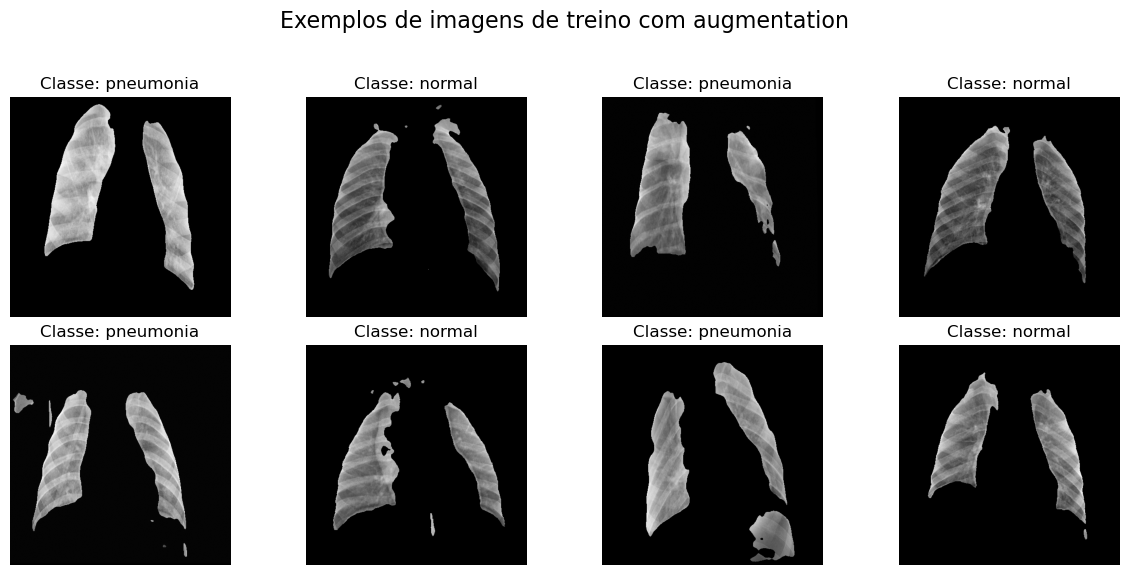

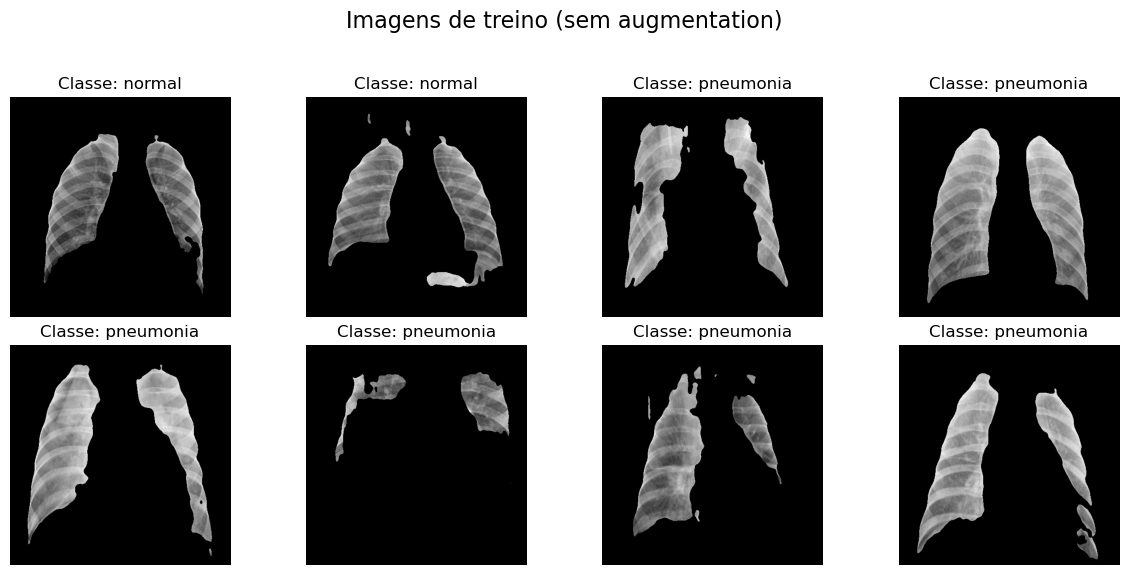

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.5])
    std = np.array([0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.imshow(inp, cmap='gray')
    if title is not None:
        plt.title(title)
    plt.axis('off')

inputs, classes = next(iter(train_loader))

plt.figure(figsize=(12, 6))
plt.suptitle("Exemplos de imagens de treino com augmentation", fontsize=16)

for i in range(8):
    plt.subplot(2, 4, i + 1)
    title = f"Classe: {class_names[classes[i]]}"
    imshow(inputs[i], title=title)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

temp_train_dataset = ImageFolder(train_dir, transform=test_val_transform)
temp_train_loader = DataLoader(temp_train_dataset, batch_size=8, shuffle=True)

inputs_clean, classes_clean = next(iter(temp_train_loader))

plt.figure(figsize=(12, 6))
plt.suptitle("Imagens de treino (sem augmentation)", fontsize=16)

for i in range(8):
    plt.subplot(2, 4, i + 1)
    
    title = f"Classe: {class_names[classes_clean[i]]}"
    
    imshow(inputs_clean[i], title=title)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Distribuição de Classes (Train set)

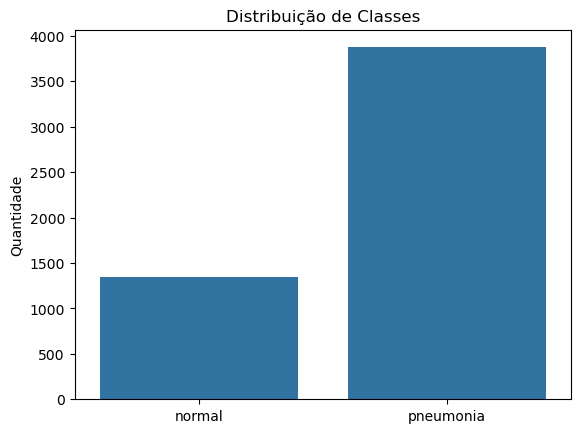

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

label_counts = Counter(train_dataset.targets)
sns.barplot(x=train_dataset.classes, y=[label_counts[i] for i in range(len(train_dataset.classes))])
plt.title("Distribuição de Classes")
plt.ylabel("Quantidade")
plt.show()

***

In [8]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Trata desequilíbrio de classes: Loss ponderada

In [9]:
all_labels = train_dataset.targets  

class_weights = compute_class_weight(
    class_weight='balanced',       
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

print("Pesos das classes:", class_weights)

Pesos das classes: tensor([1.9448, 0.6730], device='cuda:0')


In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Estratégia de treinamento em duas etapas

O treinamento foi realizado em duas fases:

### 1. Aquecimento
Na primeira etapa, a maior parte da rede foi congelada, treinando apenas as camadas mais diretamente relacionadas à adaptação do modelo ao novo domínio.

Essa fase permite estabilizar a nova cabeça de classificação e a adaptação inicial ao problema.

### 2. Fine-tuning
Na segunda etapa, todas as camadas foram liberadas para treinamento, permitindo um ajuste mais refinado dos pesos pré-treinados ao domínio das radiografias.

Foram utilizadas taxas de aprendizado menores para o corpo da rede, preservando o conhecimento previamente aprendido, enquanto o ajuste das camadas mais novas ocorreu de forma controlada.

Também foram utilizadas estratégias como:
- redução automática da taxa de aprendizado
- salvamento do melhor modelo
- early stopping

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt

model = models.resnet18(weights="IMAGENET1K_V1")
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

LR_CABECA = 1e-3
LR_CORPO = 1e-5
NUM_EPOCAS_AQUECIMENTO = 5
NUM_EPOCAS_FINETUNING = 45
PATIENCE = 5
best_val_acc = 0
early_stop_counter = 0

criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Etapa 1: aquecimento")

for param in model.parameters():
    param.requires_grad = False
for param in model.conv1.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_CABECA)

for epoch in range(NUM_EPOCAS_AQUECIMENTO):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Etapa 1 - Época {epoch+1}/{NUM_EPOCAS_AQUECIMENTO} [Treino]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Etapa 1 - Época {epoch+1}/{NUM_EPOCAS_AQUECIMENTO} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    val_loss /= total
    val_acc = correct / total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"\nÉpoca {epoch+1} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_pneumonia_best.pth")
        print("📌 Melhor modelo salvo durante aquecimento.")

print("\nEtapa 2: fine-tuning")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {'params': model.layer1.parameters(), 'lr': LR_CORPO},
    {'params': model.layer2.parameters(), 'lr': LR_CORPO},
    {'params': model.layer3.parameters(), 'lr': LR_CORPO},
    {'params': model.layer4.parameters(), 'lr': LR_CORPO},
    {'params': model.conv1.parameters(), 'lr': LR_CABECA / 10},
    {'params': model.fc.parameters(), 'lr': LR_CABECA / 10}
])
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2, min_lr=1e-7)

for epoch in range(NUM_EPOCAS_FINETUNING):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Etapa 2 - Época {epoch+1}/{NUM_EPOCAS_FINETUNING} [Treino]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Etapa 2 - Época {epoch+1}/{NUM_EPOCAS_FINETUNING} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    val_loss /= total
    val_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nÉpoca {epoch+1} | LR: {current_lr:.7f} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_pneumonia.pth")
        print("📌 Melhor modelo salvo durante fine-tuning.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("⏹️ Early stopping acionado.")
            break

print("\n✅ Treinamento finalizado.")
model.load_state_dict(torch.load("resnet18_pneumonia.pth"))

Etapa 1: aquecimento


Etapa 1 - Época 1/5 [Val]: 100%|███████████████████████████████████████████████████████| 80/80 [00:10<00:00,  7.86it/s]



Época 1 | Train Loss: 0.3418, Acc: 0.8439 | Val Loss: 0.9964, Acc: 0.6266
📌 Melhor modelo salvo durante aquecimento.


Etapa 1 - Época 2/5 [Val]: 100%|███████████████████████████████████████████████████████| 80/80 [00:09<00:00,  8.26it/s]



Época 2 | Train Loss: 0.2853, Acc: 0.8794 | Val Loss: 0.5133, Acc: 0.7500
📌 Melhor modelo salvo durante aquecimento.


...


Época 10 | LR: 0.0000030 | Train Loss: 0.0336, Acc: 0.9895 | Val Loss: 0.7167, Acc: 0.8484


Etapa 2 - Época 11/45 [Val]: 100%|█████████████████████████████████████████████████████| 80/80 [00:12<00:00,  6.53it/s]


Época 11 | LR: 0.0000030 | Train Loss: 0.0358, Acc: 0.9900 | Val Loss: 0.7105, Acc: 0.8359
⏹️ Early stopping acionado.

✅ Treinamento finalizado.



C:\Users\Disas\AppData\Local\Temp\ipykernel_28496\3303561569.py:148: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet18_pneumonia.pth"

<All keys matched successfully>

# Curva de Aprendizado (Loss e Acurácia)

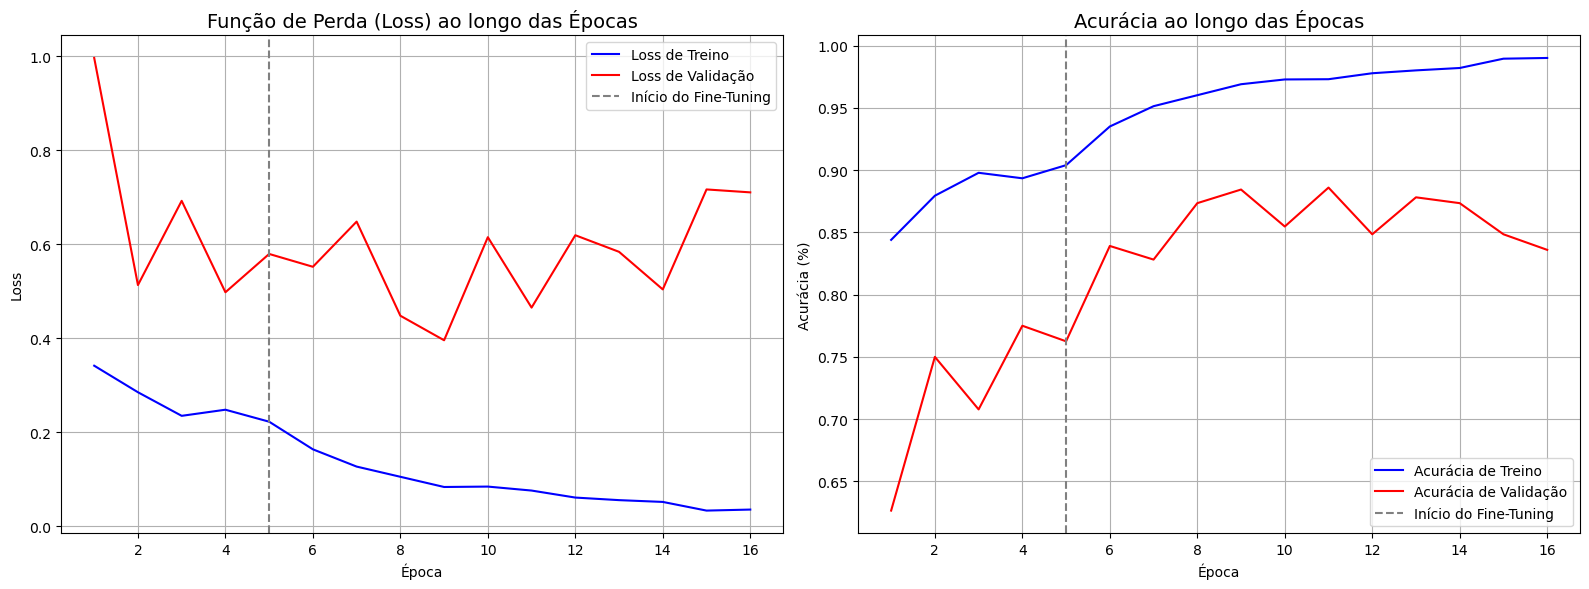

In [12]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Loss de Treino')
plt.plot(epochs_range, val_losses, 'r-', label='Loss de Validação')
plt.axvline(x=NUM_EPOCAS_AQUECIMENTO, color='grey', linestyle='--', label='Início do Fine-Tuning')
plt.title("Função de Perda (Loss) ao longo das Épocas", fontsize=14)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, 'b-', label='Acurácia de Treino')
plt.plot(epochs_range, val_accuracies, 'r-', label='Acurácia de Validação')
plt.axvline(x=NUM_EPOCAS_AQUECIMENTO, color='grey', linestyle='--', label='Início do Fine-Tuning')
plt.title("Acurácia ao longo das Épocas", fontsize=14)
plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Curva ROC

Calculando Curva ROC: 100%|██████████████████████████████████████████████████████████| 354/354 [00:33<00:00, 10.52it/s]


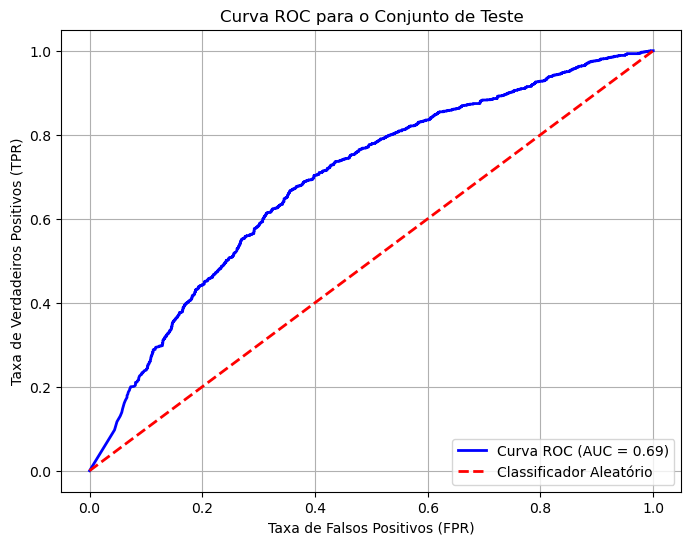

In [13]:
model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Calculando Curva ROC"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        
        probabilities = F.softmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        
        y_scores.extend(probabilities[:, 1].cpu().numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

auc_score = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Classificador Aleatório') 
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC para o Conjunto de Teste')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Avaliação no Conjunto de Teste

              precision    recall  f1-score   support

      normal       0.71      0.34      0.46      1400
   pneumonia       0.57      0.87      0.69      1431

    accuracy                           0.61      2831
   macro avg       0.64      0.60      0.58      2831
weighted avg       0.64      0.61      0.58      2831



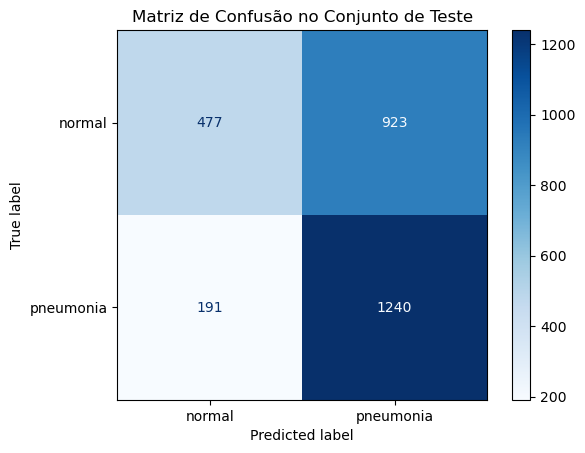

In [14]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) 
        y_true.extend(labels.cpu().numpy())    
        y_pred.extend(predicted.cpu().numpy()) 

class_names = ['normal', 'pneumonia']
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão no Conjunto de Teste")
plt.show()

# Análise Comparativa Visual

C:\Users\Disas\AppData\Local\Temp\ipykernel_28496\4198233767.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet18_pneumonia.pth"))




Dataset pediátrico


C:\Users\Disas\anaconda3\envs\xray_model\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
C:\Users\Disas\AppData\Local\Temp\ipykernel_28496\3623633629.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap.cpu(), 0) # ReLU


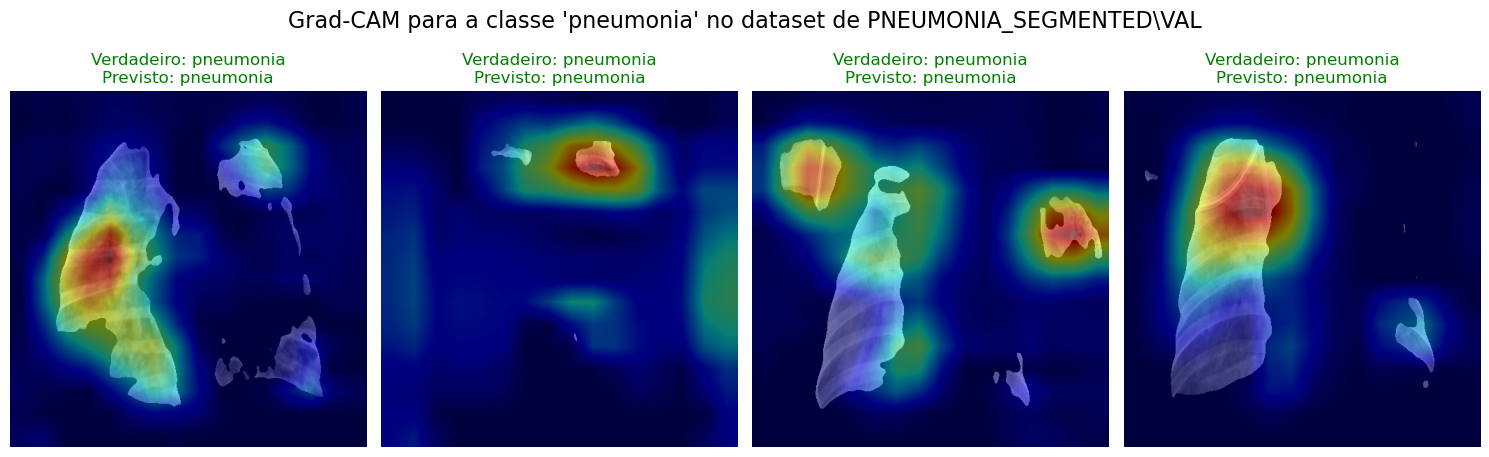

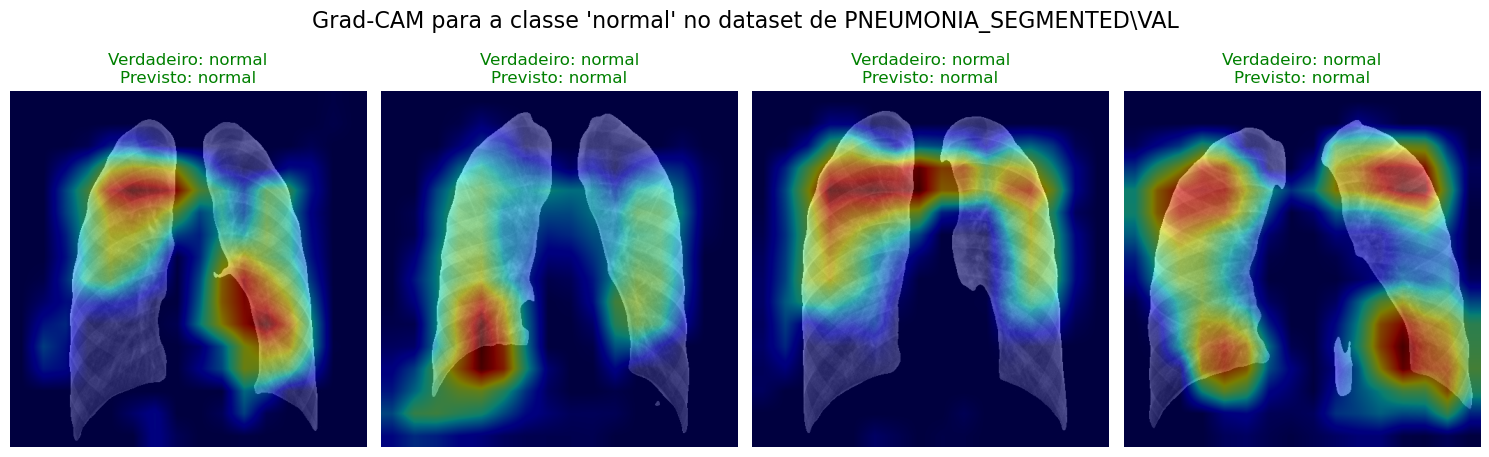



 Dataset com maioria adultos


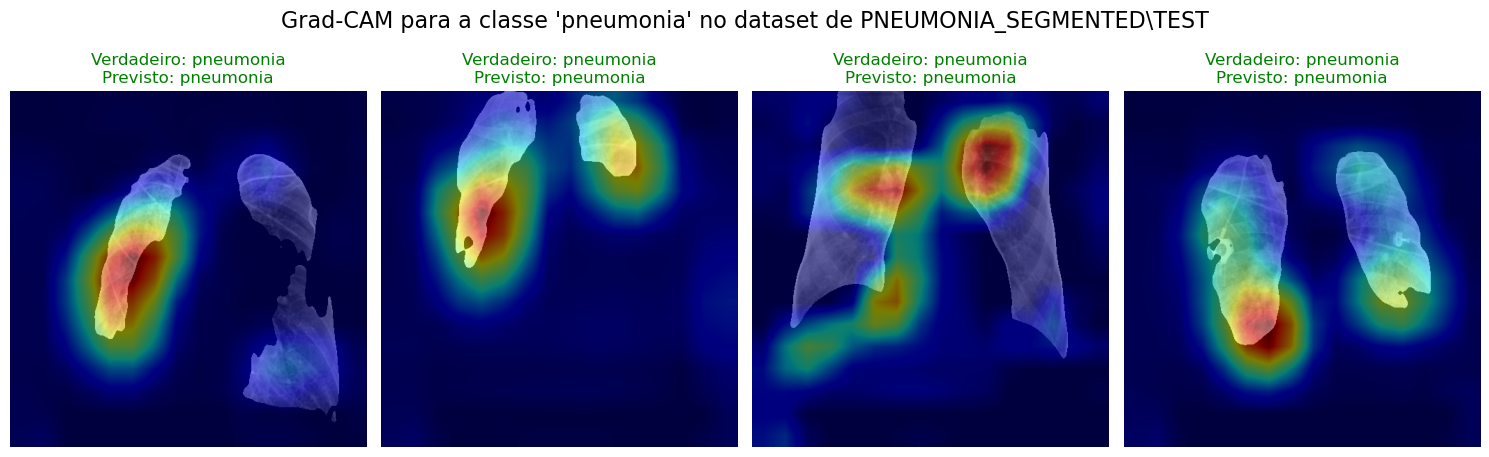

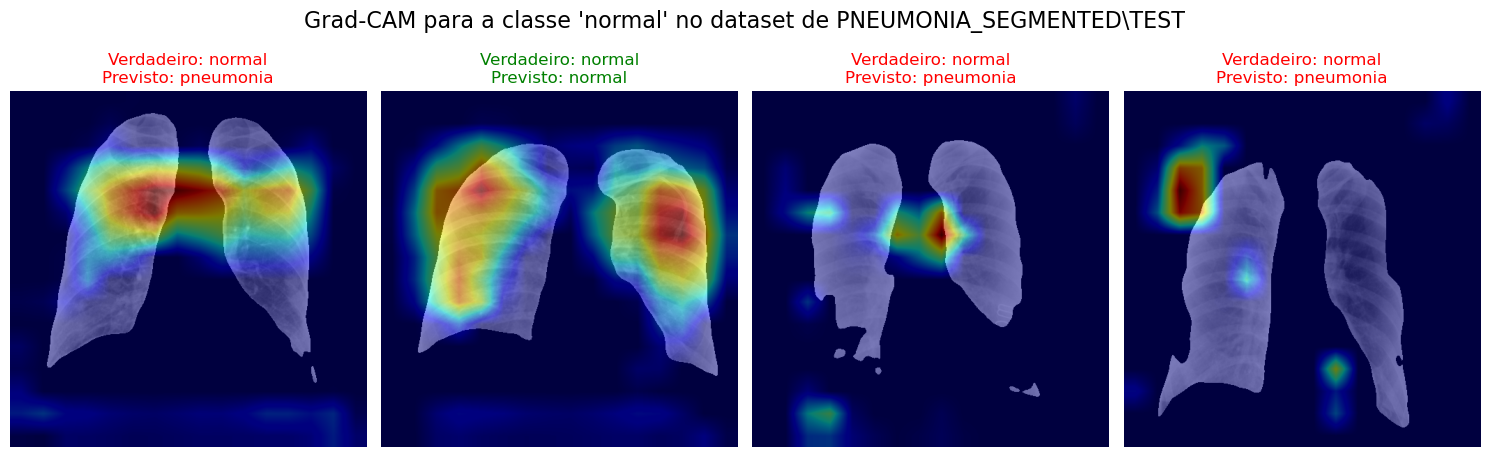

In [15]:
model.load_state_dict(torch.load("resnet18_pneumonia.pth"))
model = model.to(device)
model.eval()

target_layer = model.layer4[-1] 

grad_cam = GradCAM(model=model, target_layer=target_layer)

print("\n\nDataset pediátrico")
show_gradcam_results(val_loader, grad_cam, class_names, target_class_name='pneumonia', num_images=4)
show_gradcam_results(val_loader, grad_cam, class_names, target_class_name='normal', num_images=4)


print("\n\n Dataset com maioria adultos")
show_gradcam_results(test_loader, grad_cam, class_names, target_class_name='pneumonia', num_images=4)
show_gradcam_results(test_loader, grad_cam, class_names, target_class_name='normal', num_images=4)